In [27]:
import pandas as pd
import numpy as np
from datasets import load_dataset, concatenate_datasets
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter

import re
import string

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Load Dataset

In [28]:
dataset_dict = load_dataset("stanfordnlp/imdb")
train_reviews = dataset_dict["train"].to_pandas()
test_reviews = dataset_dict["test"].to_pandas()

## Text preprocessing

The raw reviews are HTML-style text, so before vectorizing we apply, document by document:

- **lowercase**;
- keep `<br />` line breaks as a literal `br` token (so they survive the other steps);
- remove URLs, numbers, punctuation and other non-word characters.
- collapse whitespace.

This cleaning is applied per document, so it cannot leak information from the test set into training.


In [ ]:
from preprocessor import clean_text

train_reviews['clean_text'] = train_reviews['text'].apply(clean_text)
test_reviews['clean_text'] = test_reviews['text'].apply(clean_text)

## Dataset overview

We check the sizes, the class balance, the review lengths and a few examples.


In [30]:
X_train, y_train = train_reviews["clean_text"], train_reviews["label"]
X_test, y_test = test_reviews["clean_text"], test_reviews["label"]

In [31]:
print(f"Training instances: {len(X_train):,}")
print(f"Test instances: {len(X_test):,}")

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nExample SMS:")
display(train_reviews[['text', 'label']].sample(4))

Training instances: 25,000
Test instances: 25,000

Training class distribution:
label
0    12500
1    12500
Name: count, dtype: int64

Example SMS:


,text,label
23634,"There was a stylish approach to this film on the part of director Vincenzo Natali with interesting camera angles and effective close-ups. It was also refreshing to see Jeremy Northam and Lucy Liu given leading roles and expanding their range as performers. This film also included one of the most imaginative ""escape"" scenes in recent years. The efforts of the director and the actors combined in an effective thriller.<br /><br />Although the plotting of the film was convoluted, the story progressed very clearly as the layers of corporate greed and skullduggery were revealed.<br /><br />In 1949, George Orwell suggested in his famous novel ""1984"" that the future would be ruled by the totalitarian State, which would control minds and diminish human liberty. It was interesting that in this intriguing futuristic film, it was not the State, but rather the corporate world that controlled and devalued the human worker.",1
12626,"If you like adult comedy cartoons, like South Park, then this is nearly a similar format about the small adventures of three teenage girls at Bromwell High. Keisha, Natella and Latrina have given exploding sweets and behaved like bitches, I think Keisha is a good leader. There are also small stories going on with the teachers of the school. There's the idiotic principal, Mr. Bip, the nervous Maths teacher and many others. The cast is also fantastic, Lenny Henry's Gina Yashere, EastEnders Chrissie Watts, Tracy-Ann Oberman, Smack The Pony's Doon Mackichan, Dead Ringers' Mark Perry and Blunder's Nina Conti. I didn't know this came from Canada, but it is very good. Very good!",1
12424,"Hm. While an enjoyable movie to poke plot holes, point out atrocious acting, primitive (at best) special effects (all of which have caused me to view this movie three times over the past six years), Severed ranks among the worst I've ever seen. I'm never sure who the protagonists are, all I know is that the killer uses a portable guillotine, as seen in the dance floor murder scene. All in all, I don't really like the movie, because only the first 30 minutes are enjoyable, the rest is a mishmash of confusing dialog and imagery that fail to progress the story to a logical conclusion (which I can't remember anyway).",0
858,"Robert Wagner is the evil boss of Digicron, a telecommunications company with a virus that kills people.<br /><br />'so you're saying that the software virus has become a real virus that can kill people - that may be medically possible but not possible from my system' <br /><br />'i'm having to write some new virus software of my own to trap it - it may take some time'<br /><br />'but it's not going after software, it's killing people'<br /><br />watch out for the 'i'm into virology' love moment and perhaps first ever film plot to feature death by braille keyboard",0


# Baseline: Logistic Regression Classification

In [32]:
clf_base = Pipeline(
    steps=[
        ("vectorizer", CountVectorizer(
            ngram_range=(1,1),
            min_df=5,
            max_df=0.95,
        )),
        ("clf", LogisticRegression(
            max_iter=1000
        ))
    ]
)

clf_base.fit(X_train, y_train)

y_base = clf_base.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_base))


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87     12500
           1       0.87      0.86      0.86     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



In [33]:
len(clf_base.named_steps['vectorizer'].vocabulary_)

28346

In [34]:
print("Accuracy:", accuracy_score(y_test, y_base))

Accuracy: 0.866


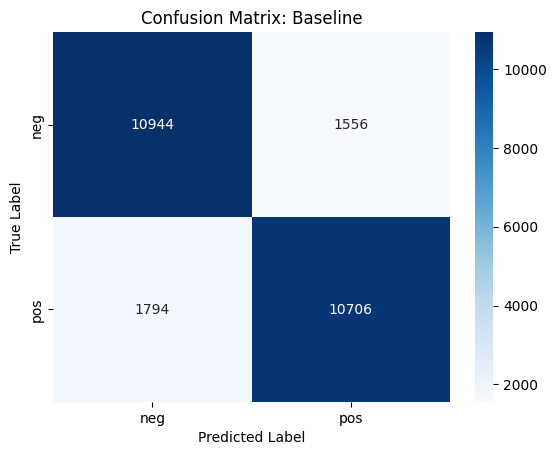

In [35]:
cm = confusion_matrix(y_test, y_base)
classes = ["neg", "pos"]
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
  )
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Baseline")
plt.show()

# Limitations: Error Analysis

In [36]:
y_prob = clf_base.predict_proba(X_test)
test_errors = (y_base != y_test.to_numpy())
error_idx = np.flatnonzero(test_errors)
conf = y_prob[np.arange(len(y_test)), y_base]

In [37]:
errors_df = pd.DataFrame({
    "text": test_reviews['text'].iloc[error_idx].to_numpy(),
    "clean_text": X_test.iloc[error_idx].to_numpy(),
    "true_label": y_test.iloc[error_idx].to_numpy(),
    "prediction": y_base[error_idx],
    "prediction_prob": conf[error_idx]
})

errors_df = errors_df.sort_values(
    "prediction_prob", ascending=False
).reset_index(drop=True)

errors_df.to_csv("imdb_sentiment_baseline_errors.csv")

In [38]:
cust_tests = [
    "This movie is good.",
    "This movie is not good.",
    "The plot is boring.",
    "The plot is not boring.",
]
pos_prob = clf_base.predict_proba(cust_tests)[:, 1]
cust_preds = clf_base.predict(cust_tests)

cust_tests_results_df = pd.DataFrame({
    "Text": cust_tests,
    "Prediction": cust_preds,
    "True Label": [1, 0, 0, 1],
    "P(pos|x)": pos_prob
})
cust_tests_results_df

,Text,Prediction,True Label,P(pos|x)
0,This movie is good.,1,1,0.585236
1,This movie is not good.,1,0,0.532989
2,The plot is boring.,0,0,0.169003
3,The plot is not boring.,0,1,0.141260


In [39]:
not_idx = clf_base.named_steps["vectorizer"].vocabulary_["not"]
good_idx = clf_base.named_steps["vectorizer"].vocabulary_["good"]
w_not = clf_base.named_steps["clf"].coef_[0, not_idx]
w_good = clf_base.named_steps["clf"].coef_[0, good_idx]
print(f"weight('not')  = {w_not:.3f}")
print(f"weight('good') = {w_good:.3f}")

weight('not')  = -0.212
weight('good') = 0.258


# Improvement: Negation Handling

In [40]:
NEGATION_CUES = {
  "not", "no", "never", "nothing", "none", "nor", "neither", "nobody",
  "hardly", "barely", "scarcely", "without", "cannot", "cant",
  "wont", "dont", "doesnt", "didnt", "isnt", "arent", "wasnt", "werent",
  "hasnt", "havent", "hadnt", "couldnt", "wouldnt", "shouldnt", "mustnt",
}

BOUNDARY_TOKENS = {".", ",", ";", "!", "?", "but", "however", "though", "although", "br"}

def make_negation_analyzer(window):
    def analyzer(text):
        tokens = re.findall(r"[a-z]+", text)
        out = []
        remaining = 0
        for i, tok in enumerate(tokens):

            if tok in NEGATION_CUES:
                nxt = tokens[i + 1] if i + 1 < len(tokens) else ""
                # boundary case: not only
                if tok == "not" and nxt == "only":
                    remaining = 0
                else:
                    remaining = window
                out.append(tok)

            elif tok in BOUNDARY_TOKENS:
                remaining = 0
                out.append(tok)

            # add prefix
            elif remaining > 0:
                out.append("NOT_" + tok)
                remaining -= 1

            else:
                out.append(tok)
        return out
    return analyzer


In [41]:
clf_neg = Pipeline(
    steps=[
        ("vectorizer", CountVectorizer(
            analyzer=make_negation_analyzer(3),
            min_df=5,
            max_df=0.95,
        )),
        ("clf", LogisticRegression(
            max_iter=1000
        ))
    ]
)

clf_neg.fit(X_train, y_train)

y_neg = clf_neg.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_neg))


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87     12500
           1       0.88      0.87      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



In [42]:
print("Accuracy:", accuracy_score(y_test, y_neg))

Accuracy: 0.87396


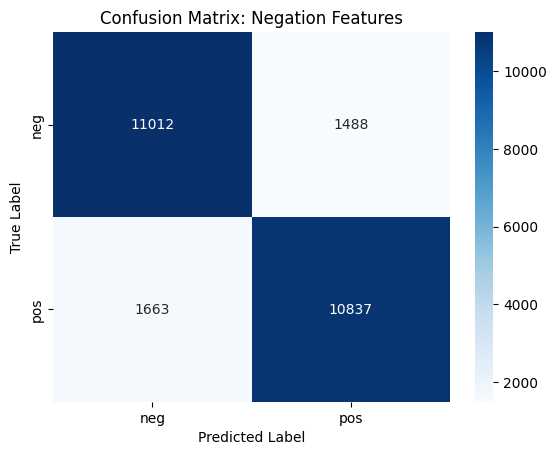

In [43]:
cm = confusion_matrix(y_test, y_neg)
classes = ["neg", "pos"]
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
  )
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Negation Features")
plt.show()

In [44]:
cust_tests_results_imprv_df = pd.DataFrame({
    "Text": cust_tests,
    "Prediction": clf_neg.predict(cust_tests),
    "True Label": [1, 0, 0, 1],
    "P(pos|x)": clf_neg.predict_proba(cust_tests)[:, 1]
})
cust_tests_results_imprv_df

,Text,Prediction,True Label,P(pos|x)
0,This movie is good.,1,1,0.625468
1,This movie is not good.,0,0,0.384213
2,The plot is boring.,0,0,0.154414
3,The plot is not boring.,1,1,0.559178


In [45]:
hard_examples = [
    ("not very good (neg)", 0,
     "sadly this movie is not very good but does it really matter we all know the basics for the story and this has nothing new but i love low budget horror sci fic camp classics so i forgive this one about thew only thing that anyone remember from this movie is that little leonardo dicaprio made his debut in it br br he did ok the part didnt ask for great acting skills and the direction probably never gave him any chance of providing one anyway little leonardo dicaprio was very cute and so was the girl the movie is fun if you like horror sci fic camp classics and are experienced in watching them"),
    ("didn't like (neg)", 0,
     "i checked out this video expecting to like it wanting to like it i like foreign films i like beautiful cinematography i know the critics liked this film including my favorite roger ebert and i dont mind slow films br br well its beautiful thats about the best i can say for it the plot is very thin the shots are very long the glances are very meaningful the actors are very sincere and it seems like a very long movie i fell asleep half way though it woke up rewound the tape tried again it was a trial but i made it to the end i didnt like it any better for that"),
    ("isn't bad (pos)", 1,
     "ok when i rented this several years ago i had the worst expectations yes the acting isnt great and the picture itself looks dated but as i sat there a strange thing happened i started to like it the action is great and there are few scenes that make you jump brion james maybe one of the greatest bgrade actors next to bruce campbell is great as always the story isnt bad either now i wouldnt rush out and buy it but you wont waste your time at least watching this good bgrade post apocalyptic western"),
]

texts = [t for _, _, t in hard_examples]
hard_df = pd.DataFrame({
    "Example": [n for n, _, _ in hard_examples],
    "True label": [lbl for _, lbl, _ in hard_examples],
    "Baseline pred": clf_base.predict(texts),
    "Baseline P(pos|x)": clf_base.predict_proba(texts)[:, 1],
    "Negation pred": clf_neg.predict(texts),
    "Negation P(pos|x)": clf_neg.predict_proba(texts)[:, 1],
})
hard_df.round(3)


,Example,True label,Baseline pred,Baseline P(pos|x),Negation pred,Negation P(pos|x)
0,not very good (neg),0,1,0.559,0,0.050
1,didn't like (neg),0,1,0.979,1,0.994
2,isn't bad (pos),1,0,0.001,0,0.005


## Comparison: baseline vs. improvement

In [46]:
def summarize(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Recall (negative)": recall_score(y_true, y_pred, pos_label=0),
        "Recall (positive)": recall_score(y_true, y_pred, pos_label=1),
        "False negatives": fn,
        "False positives": fp,
    }

comparison = pd.DataFrame({
    "Baseline": summarize(y_test, y_base),
    "Negation features": summarize(y_test, y_neg),
})
comparison.round(3)


,Baseline,Negation features
Accuracy,0.866,0.874
Macro F1,0.866,0.874
Recall (negative),0.876,0.881
Recall (positive),0.856,0.867
False negatives,1794.000,1663.000
False positives,1556.000,1488.000


# Further improvements

In [47]:
clf_bigram = Pipeline(
    steps=[
        ("vectorizer", CountVectorizer(
            ngram_range=(1,2),
            min_df=5,
            max_df=0.95
        )),
        ("clf", LogisticRegression(
            max_iter=1000
        ))
    ]
)

clf_bigram.fit(X_train, y_train)

y_bigram = clf_bigram.predict(X_test)

print("Classification report (bigrams 1-2):")
print(classification_report(y_test, y_bigram, digits=4))
print("Accuracy:", accuracy_score(y_test, y_bigram))
print("Vocabulary size:", len(clf_bigram.named_steps["vectorizer"].vocabulary_))

Classification report (bigrams 1-2):
              precision    recall  f1-score   support

           0     0.8956    0.8942    0.8949     12500
           1     0.8943    0.8958    0.8950     12500

    accuracy                         0.8950     25000
   macro avg     0.8950    0.8950    0.8950     25000
weighted avg     0.8950    0.8950    0.8950     25000

Accuracy: 0.89496
Vocabulary size: 154192


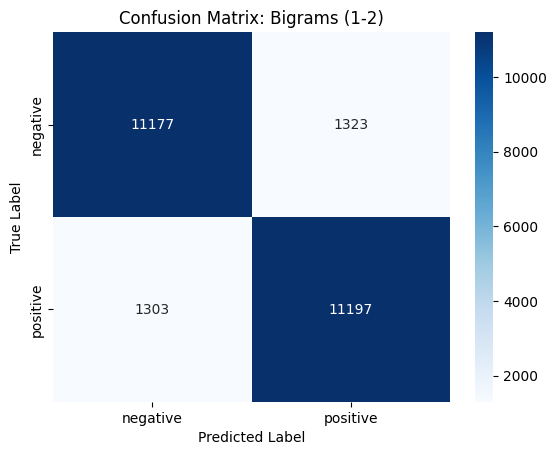

In [48]:
cm = confusion_matrix(y_test, y_bigram)
classes = ["negative", "positive"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Bigrams (1-2)")
plt.show()

In [49]:
import joblib

joblib.dump(clf_bigram, "sentiment_model.pkl")

['sentiment_model.pkl']